# Mushroom Classifier
This model's goal is to classify images of mushrooms and determine whether they are poisonous or safe.  

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

C:\Users\Omistaja\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


tensorflow


In [2]:
from sklearn.model_selection import train_test_split
batch_size_n = 32
img_size = (224, 224)

# Load images
dataset = keras.utils.image_dataset_from_directory(
    '../datasets/mushroom',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    labels='inferred',
    label_mode='categorical',
    shuffle=True,
    seed=123)

num_classes = len(dataset.class_names)

Found 6714 files belonging to 9 classes.


In [3]:
# Split dataset into validation and training
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)

train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size).take(val_size)
test_dataset = dataset.skip(train_size + val_size)

In [4]:
# Prefetch datasets to improve performance
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
# Data augmentation to diversify content
from keras import Sequential
from keras import layers
from keras.optimizers import Adam

data_augmentation = Sequential([
    # preprocess
    layers.Rescaling(1./255),
    # augment
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

In [6]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,

    # Convolution
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Output
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,921 (433.29 KB)

 Trainable params: 110,921 (433.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer=Adam(learning_rate = 0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
from keras.callbacks import EarlyStopping

history = model.fit(
    train_dataset,
    batch_size=batch_size_n,
    epochs=64,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.1858 - loss: 2.1022 - val_accuracy: 0.2359 - val_loss: 2.0363
Epoch 2/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.2051 - loss: 2.0613 - val_accuracy: 0.2359 - val_loss: 2.0218
Epoch 3/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.2130 - loss: 2.0404 - val_accuracy: 0.2349 - val_loss: 2.0043
Epoch 4/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.2194 - loss: 2.0173 - val_accuracy: 0.2177 - val_loss: 1.9937
Epoch 5/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.2243 - loss: 2.0030 - val_accuracy: 0.2399 - val_loss: 1.9746
Epoch 6/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.2268 - loss: 1.9944 - val_accuracy: 0.2399 - val_loss: 1.9674
Epoch 7/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.2273 - loss: 1.9888 - val_accuracy: 0.2450 - val_loss: 1.9595
Epoch 8/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - accuracy: 0.2281 - loss: 1

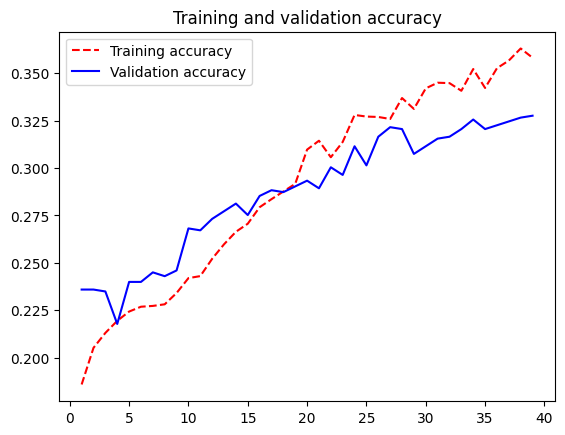

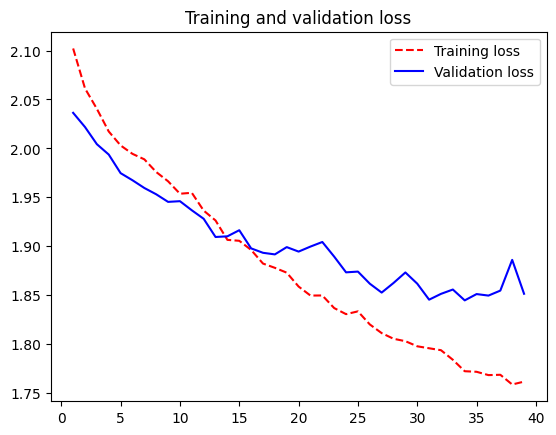

In [9]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [10]:
loss, acc = model.evaluate(test_dataset, verbose=0)
print(f"The model's test accuracy is {acc}")

The model's test accuracy is 0.31532415747642517
